In [2]:
import pandas as pd
import numpy as np

business_df = pd.read_csv("../data/trustmesh_economic_data.csv")
business_df["month"] = pd.to_datetime(business_df["month"])

business_profiles = (
    business_df
    .sort_values("month")
    .groupby("business_id")
    .tail(1)
    .reset_index(drop=True)
)

print("Business profiles:", business_profiles.shape)

Business profiles: (500, 32)


In [3]:
twin_cols = [
    "business_id",
    "business_type",
    "environment_type",
    "location",
    "monthly_income",
    "monthly_expenses",
    "net_cash_flow",
    "cash_flow_margin_pct",
    "savings_amount",
    "financial_health_pct",
    "operational_stability_pct",
    "resilience_pct",
    "payment_discipline_pct",
    "supplier_reliability_pct",
    "business_continuity_pct",
    "demand_stability_pct",
    "digital_payment_pct",
    "economic_reputation_index",
    "shock_type",
    "shock_factor"
]

business_twins = business_profiles[twin_cols].copy()

print("Business Twin dataset:", business_twins.shape)
business_twins.head()

Business Twin dataset: (500, 20)


,business_id,business_type,environment_type,location,monthly_income,monthly_expenses,net_cash_flow,cash_flow_margin_pct,savings_amount,financial_health_pct,operational_stability_pct,resilience_pct,payment_discipline_pct,supplier_reliability_pct,business_continuity_pct,demand_stability_pct,digital_payment_pct,economic_reputation_index,shock_type,shock_factor
0,B490,Micro Service Business,Semi-Urban,Ahmedabad,27760.10,14541.57,6448.86,36.03,1387.81,52.27,84.75,87.47,76.61,88.58,86.33,87.49,63.70,72.30,NaN,1.00
1,B481,Food Vendor,Semi-Urban,Jaipur,25001.33,15934.41,1457.13,-4.64,188.13,26.16,71.69,72.38,69.63,71.30,77.20,68.63,29.55,55.48,Demand Drop,0.75
2,B486,Retail Shop,Urban,Ahmedabad,48171.91,37044.09,-338.57,-6.27,220.37,25.34,81.60,81.84,80.88,72.97,93.76,78.79,60.49,61.81,Supply Disruption,0.85
3,B497,Artisan,Semi-Urban,Bengaluru,29610.68,18169.77,3623.27,26.86,367.53,46.59,78.31,77.95,79.38,71.02,83.51,79.32,34.43,67.35,NaN,1.00
4,B493,Retail Shop,Urban,Indore,46169.80,32564.23,2951.18,21.99,998.63,44.32,75.72,71.55,88.24,66.15,87.94,60.56,65.51,66.40,NaN,1.00


In [4]:
business_twins["current_status"] = np.where(
    business_twins["shock_type"].isna(),
    "Stable",
    business_twins["shock_type"]
)

print(business_twins["current_status"].value_counts())

current_status
Stable                     407
Demand Drop                 38
Supply Disruption           33
Operating Cost Increase     22
Name: count, dtype: int64


In [5]:
business_twins["baseline_cash_flow"] = business_twins["net_cash_flow"]
business_twins["baseline_income"] = business_twins["monthly_income"]
business_twins["baseline_expenses"] = business_twins["monthly_expenses"]

print(
    business_twins[
        ["business_id", "baseline_income", "baseline_expenses", "baseline_cash_flow"]
    ].head()
)

  business_id  baseline_income  baseline_expenses  baseline_cash_flow
0        B490         27760.10           14541.57             6448.86
1        B481         25001.33           15934.41             1457.13
2        B486         48171.91           37044.09             -338.57
3        B497         29610.68           18169.77             3623.27
4        B493         46169.80           32564.23             2951.18


In [6]:
business_twins["sim_income_demand_drop"] = (
    business_twins["baseline_income"] * business_twins["shock_factor"]
)

business_twins["sim_cash_flow_demand_drop"] = (
    business_twins["sim_income_demand_drop"]
    - business_twins["baseline_expenses"]
)

print(
    business_twins[
        [
            "business_id",
            "baseline_cash_flow",
            "sim_income_demand_drop",
            "sim_cash_flow_demand_drop"
        ]
    ].head()
)

  business_id  baseline_cash_flow  sim_income_demand_drop  \
0        B490             6448.86              27760.1000   
1        B481             1457.13              18750.9975   
2        B486             -338.57              40946.1235   
3        B497             3623.27              29610.6800   
4        B493             2951.18              46169.8000   

   sim_cash_flow_demand_drop  
0                 13218.5300  
1                  2816.5875  
2                  3902.0335  
3                 11440.9100  
4                 13605.5700  


In [7]:
demand_drop_factor = 0.80

business_twins["sim_income_demand_drop"] = (
    business_twins["baseline_income"] * demand_drop_factor
)

business_twins["sim_cash_flow_demand_drop"] = (
    business_twins["sim_income_demand_drop"]
    - business_twins["baseline_expenses"]
)

business_twins["cash_flow_change_pct"] = (
    (
        business_twins["sim_cash_flow_demand_drop"]
        - business_twins["baseline_cash_flow"]
    )
    / business_twins["baseline_cash_flow"].replace(0, np.nan)
    * 100
).round(2)

print(
    business_twins[
        ["business_id", "baseline_cash_flow",
         "sim_cash_flow_demand_drop", "cash_flow_change_pct"]
    ].head()
)

  business_id  baseline_cash_flow  sim_cash_flow_demand_drop  \
0        B490             6448.86                   7666.510   
1        B481             1457.13                   4066.654   
2        B486             -338.57                   1493.438   
3        B497             3623.27                   5518.774   
4        B493             2951.18                   4371.610   

   cash_flow_change_pct  
0                 18.88  
1                179.09  
2               -541.10  
3                 52.31  
4                 48.13  


In [8]:
business_twins["cash_flow_impact"] = (
    business_twins["sim_cash_flow_demand_drop"]
    - business_twins["baseline_cash_flow"]
).round(2)

print(
    business_twins[
        ["business_id", "baseline_cash_flow",
         "sim_cash_flow_demand_drop", "cash_flow_impact"]
    ].head()
)

  business_id  baseline_cash_flow  sim_cash_flow_demand_drop  cash_flow_impact
0        B490             6448.86                   7666.510           1217.65
1        B481             1457.13                   4066.654           2609.52
2        B486             -338.57                   1493.438           1832.01
3        B497             3623.27                   5518.774           1895.50
4        B493             2951.18                   4371.610           1420.43


In [9]:
business_twins["demand_drop_status"] = np.where(
    business_twins["sim_cash_flow_demand_drop"] < 0,
    "At Risk",
    "Stable"
)

print(business_twins["demand_drop_status"].value_counts())

demand_drop_status
Stable     498
At Risk      2
Name: count, dtype: int64


In [10]:
at_risk = business_twins[
    business_twins["demand_drop_status"] == "At Risk"
][
    [
        "business_id",
        "business_type",
        "location",
        "baseline_cash_flow",
        "sim_cash_flow_demand_drop",
        "financial_health_pct",
        "resilience_pct",
        "economic_reputation_index"
    ]
].sort_values("sim_cash_flow_demand_drop")

at_risk

,business_id,business_type,location,baseline_cash_flow,sim_cash_flow_demand_drop,financial_health_pct,resilience_pct,economic_reputation_index
311,B383,Retail Shop,Jaipur,-3821.99,-348.276,33.83,79.66,63.35
155,B045,Retail Shop,Delhi,-1184.70,-218.980,37.57,87.62,69.55


In [11]:
print("Average baseline cash flow:",
      round(business_twins["baseline_cash_flow"].mean(), 2))

print("Average simulated cash flow:",
      round(business_twins["sim_cash_flow_demand_drop"].mean(), 2))

print("Businesses with lower cash flow:",
      (business_twins["cash_flow_impact"] < 0).sum())

Average baseline cash flow: 5475.68
Average simulated cash flow: 6571.27
Businesses with lower cash flow: 180


In [12]:
business_twins[
    [
        "business_id",
        "business_type",
        "location",
        "baseline_cash_flow",
        "sim_cash_flow_demand_drop",
        "cash_flow_impact"
    ]
].sort_values("cash_flow_impact").head(5)

,business_id,business_type,location,baseline_cash_flow,sim_cash_flow_demand_drop,cash_flow_impact
373,B445,Freelancer,Bengaluru,22935.61,18161.994,-4773.62
227,B104,Freelancer,Indore,24028.61,19505.864,-4522.75
401,B292,Freelancer,Indore,23517.70,19363.402,-4154.30
233,B063,Freelancer,Bengaluru,19798.73,15733.078,-4065.65
61,B131,Retail Shop,Patna,9338.72,5299.340,-4039.38


In [13]:
business_twins["impact_severity"] = pd.cut(
    business_twins["cash_flow_impact"],
    bins=[-np.inf, -3000, -1000, 0, np.inf],
    labels=["High", "Moderate", "Low", "No Impact"]
)

print(business_twins["impact_severity"].value_counts())

impact_severity
No Impact    320
Low           82
Moderate      75
High          23
Name: count, dtype: int64


In [14]:
def simulate_demand_drop(df, drop_pct=20):
    factor = 1 - (drop_pct / 100)

    result = df.copy()
    result["sim_income"] = result["baseline_income"] * factor
    result["sim_cash_flow"] = result["sim_income"] - result["baseline_expenses"]
    result["cash_flow_impact"] = (
        result["sim_cash_flow"] - result["baseline_cash_flow"]
    ).round(2)

    return result

In [15]:
scenario_20 = simulate_demand_drop(business_twins, 20)

print(scenario_20[["business_id", "sim_income", "sim_cash_flow", "cash_flow_impact"]].head())

  business_id  sim_income  sim_cash_flow  cash_flow_impact
0        B490   22208.080       7666.510           1217.65
1        B481   20001.064       4066.654           2609.52
2        B486   38537.528       1493.438           1832.01
3        B497   23688.544       5518.774           1895.50
4        B493   36935.840       4371.610           1420.43


In [16]:
scenario_20["risk_status"] = np.where(
    scenario_20["sim_cash_flow"] < 0,
    "At Risk",
    "Stable"
)

print(scenario_20["risk_status"].value_counts())

risk_status
Stable     498
At Risk      2
Name: count, dtype: int64


In [17]:
business_twins["income_minus_expenses"] = (
    business_twins["baseline_income"] - business_twins["baseline_expenses"]
).round(2)

print(
    business_twins[
        [
            "business_id",
            "baseline_income",
            "baseline_expenses",
            "baseline_cash_flow",
            "income_minus_expenses"
        ]
    ].head(10)
)

  business_id  baseline_income  baseline_expenses  baseline_cash_flow  \
0        B490         27760.10           14541.57             6448.86   
1        B481         25001.33           15934.41             1457.13   
2        B486         48171.91           37044.09             -338.57   
3        B497         29610.68           18169.77             3623.27   
4        B493         46169.80           32564.23             2951.18   
5        B495         40503.18           28788.54             3659.93   
6        B484         47829.39           36341.76             4192.33   
7        B491         26654.75           17904.40             4049.85   
8        B485         34604.65           22813.18             4666.19   
9        B499         27538.63           13436.47             8166.67   

   income_minus_expenses  
0               13218.53  
1                9066.92  
2               11127.82  
3               11440.91  
4               13605.57  
5               11714.64  
6      

In [18]:
# Rebuild the demand-drop scenario using each business's baseline cash-flow margin

demand_drop_pct = 20
demand_factor = 1 - (demand_drop_pct / 100)

business_twins["sim_income_demand_drop"] = (
    business_twins["baseline_income"] * demand_factor
)

business_twins["sim_cash_flow_demand_drop"] = (
    business_twins["sim_income_demand_drop"]
    * business_twins["cash_flow_margin_pct"] / 100
).round(2)

business_twins["cash_flow_impact"] = (
    business_twins["sim_cash_flow_demand_drop"]
    - business_twins["baseline_cash_flow"]
).round(2)

business_twins["demand_drop_status"] = np.where(
    business_twins["sim_cash_flow_demand_drop"] < 0,
    "At Risk",
    "Stable"
)

print(
    business_twins[
        [
            "business_id",
            "baseline_cash_flow",
            "sim_cash_flow_demand_drop",
            "cash_flow_impact",
            "demand_drop_status"
        ]
    ].head(10)
)

print("\nRisk status:")
print(business_twins["demand_drop_status"].value_counts())

  business_id  baseline_cash_flow  sim_cash_flow_demand_drop  \
0        B490             6448.86                    8001.57   
1        B481             1457.13                    -928.05   
2        B486             -338.57                   -2416.30   
3        B497             3623.27                    6362.74   
4        B493             2951.18                    8122.19   
5        B495             3659.93                    7841.42   
6        B484             4192.33                    9171.76   
7        B491             4049.85                    6254.27   
8        B485             4666.19                    7723.76   
9        B499             8166.67                    9116.39   

   cash_flow_impact demand_drop_status  
0           1552.71             Stable  
1          -2385.18            At Risk  
2          -2077.73            At Risk  
3           2739.47             Stable  
4           5171.01             Stable  
5           4181.49             Stable  
6       

In [19]:
# Summarize the 20% demand-drop scenario

scenario_summary = {
    "baseline_avg_cash_flow": business_twins["baseline_cash_flow"].mean(),
    "scenario_avg_cash_flow": business_twins["sim_cash_flow_demand_drop"].mean(),
    "avg_cash_flow_impact": business_twins["cash_flow_impact"].mean(),
    "businesses_at_risk": (business_twins["demand_drop_status"] == "At Risk").sum(),
    "businesses_stable": (business_twins["demand_drop_status"] == "Stable").sum(),
    "high_impact_businesses": (business_twins["cash_flow_impact"] < -3000).sum()
}

print("20% Demand Drop Scenario")
print("-" * 35)

for key, value in scenario_summary.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

print("\nMost affected businesses:")

print(
    business_twins[
        [
            "business_id",
            "business_type",
            "location",
            "baseline_cash_flow",
            "sim_cash_flow_demand_drop",
            "cash_flow_impact",
            "demand_drop_status"
        ]
    ]
    .sort_values("cash_flow_impact")
    .head(10)
)

20% Demand Drop Scenario
-----------------------------------
baseline_avg_cash_flow: 5475.68
scenario_avg_cash_flow: 7213.61
avg_cash_flow_impact: 1737.93
businesses_at_risk: 24
businesses_stable: 476
high_impact_businesses: 31

Most affected businesses:
    business_id   business_type   location  baseline_cash_flow  \
401        B292      Freelancer     Indore            23517.70   
229        B089      Freelancer    Lucknow            20349.22   
406        B297      Freelancer     Indore            15006.67   
20         B479      Freelancer   Guwahati            16891.94   
84         B214      Freelancer   Guwahati            12668.79   
441        B333     Retail Shop      Delhi             5218.88   
421        B252      Freelancer   Guwahati            18766.73   
89         B219  Small Producer  Bengaluru             5385.16   
44         B174     Food Vendor      Patna             4996.51   
398        B289  Small Producer   Guwahati             6385.12   

     sim_cash_flow

In [20]:
# Rebuild demand-drop simulation using baseline cash-flow conversion

demand_drop_pct = 20
demand_factor = 1 - (demand_drop_pct / 100)

business_twins["baseline_cash_flow_rate"] = (
    business_twins["baseline_cash_flow"]
    / business_twins["baseline_income"].replace(0, np.nan)
)

business_twins["sim_income_demand_drop"] = (
    business_twins["baseline_income"] * demand_factor
)

business_twins["sim_cash_flow_demand_drop"] = (
    business_twins["sim_income_demand_drop"]
    * business_twins["baseline_cash_flow_rate"]
).round(2)

business_twins["cash_flow_impact"] = (
    business_twins["sim_cash_flow_demand_drop"]
    - business_twins["baseline_cash_flow"]
).round(2)

business_twins["demand_drop_status"] = np.where(
    business_twins["sim_cash_flow_demand_drop"] < 0,
    "At Risk",
    "Stable"
)

print("Average baseline cash flow:",
      round(business_twins["baseline_cash_flow"].mean(), 2))

print("Average simulated cash flow:",
      round(business_twins["sim_cash_flow_demand_drop"].mean(), 2))

print("Average cash-flow impact:",
      round(business_twins["cash_flow_impact"].mean(), 2))

print("\nRisk status:")
print(business_twins["demand_drop_status"].value_counts())

Average baseline cash flow: 5475.68
Average simulated cash flow: 4380.55
Average cash-flow impact: -1095.14

Risk status:
demand_drop_status
Stable     466
At Risk     34
Name: count, dtype: int64


In [21]:
# Supply disruption scenario: 15% reduction in income

supply_disruption_pct = 15
supply_factor = 1 - (supply_disruption_pct / 100)

business_twins["sim_income_supply_disruption"] = (
    business_twins["baseline_income"] * supply_factor
)

business_twins["sim_cash_flow_supply_disruption"] = (
    business_twins["baseline_cash_flow"] * supply_factor
).round(2)

business_twins["supply_cash_flow_impact"] = (
    business_twins["sim_cash_flow_supply_disruption"]
    - business_twins["baseline_cash_flow"]
).round(2)

business_twins["supply_disruption_status"] = np.where(
    business_twins["sim_cash_flow_supply_disruption"] < 0,
    "At Risk",
    "Stable"
)

print("15% Supply Disruption Scenario")
print("-" * 35)

print("Average baseline cash flow:",
      round(business_twins["baseline_cash_flow"].mean(), 2))

print("Average simulated cash flow:",
      round(business_twins["sim_cash_flow_supply_disruption"].mean(), 2))

print("Average cash-flow impact:",
      round(business_twins["supply_cash_flow_impact"].mean(), 2))

print("\nRisk status:")
print(business_twins["supply_disruption_status"].value_counts())

print("\nMost affected businesses:")
print(
    business_twins[
        [
            "business_id",
            "business_type",
            "location",
            "baseline_cash_flow",
            "sim_cash_flow_supply_disruption",
            "supply_cash_flow_impact",
            "supply_disruption_status"
        ]
    ]
    .sort_values("supply_cash_flow_impact")
    .head(10)
)

15% Supply Disruption Scenario
-----------------------------------
Average baseline cash flow: 5475.68
Average simulated cash flow: 4654.33
Average cash-flow impact: -821.35

Risk status:
supply_disruption_status
Stable     466
At Risk     34
Name: count, dtype: int64

Most affected businesses:
    business_id business_type   location  baseline_cash_flow  \
227        B104    Freelancer     Indore            24028.61   
401        B292    Freelancer     Indore            23517.70   
373        B445    Freelancer  Bengaluru            22935.61   
419        B249    Freelancer   Guwahati            21277.81   
153        B030    Freelancer      Delhi            20950.27   
229        B089    Freelancer    Lucknow            20349.22   
53         B123    Freelancer    Lucknow            20089.82   
233        B063    Freelancer  Bengaluru            19798.73   
245        B075    Freelancer     Mumbai            19585.35   
266        B398    Freelancer      Patna            19172.97   


In [22]:
# Operating cost increase scenario: 15% increase in expenses

cost_increase_pct = 15
cost_factor = 1 + (cost_increase_pct / 100)

business_twins["sim_expenses_cost_increase"] = (
    business_twins["baseline_expenses"] * cost_factor
)

business_twins["sim_cash_flow_cost_increase"] = (
    business_twins["baseline_cash_flow"]
    - (
        business_twins["sim_expenses_cost_increase"]
        - business_twins["baseline_expenses"]
    )
).round(2)

business_twins["cost_cash_flow_impact"] = (
    business_twins["sim_cash_flow_cost_increase"]
    - business_twins["baseline_cash_flow"]
).round(2)

business_twins["cost_increase_status"] = np.where(
    business_twins["sim_cash_flow_cost_increase"] < 0,
    "At Risk",
    "Stable"
)

print("15% Operating Cost Increase Scenario")
print("-" * 40)

print("Average baseline cash flow:",
      round(business_twins["baseline_cash_flow"].mean(), 2))

print("Average simulated cash flow:",
      round(business_twins["sim_cash_flow_cost_increase"].mean(), 2))

print("Average cash-flow impact:",
      round(business_twins["cost_cash_flow_impact"].mean(), 2))

print("\nRisk status:")
print(business_twins["cost_increase_status"].value_counts())

print("\nMost affected businesses:")
print(
    business_twins[
        [
            "business_id",
            "business_type",
            "location",
            "baseline_cash_flow",
            "sim_cash_flow_cost_increase",
            "cost_cash_flow_impact",
            "cost_increase_status"
        ]
    ]
    .sort_values("cost_cash_flow_impact")
    .head(10)
)

15% Operating Cost Increase Scenario
----------------------------------------
Average baseline cash flow: 5475.68
Average simulated cash flow: 2372.68
Average cash-flow impact: -3103.01

Risk status:
cost_increase_status
Stable     326
At Risk    174
Name: count, dtype: int64

Most affected businesses:
    business_id business_type   location  baseline_cash_flow  \
331        B463   Retail Shop   Guwahati             4657.57   
467        B346   Retail Shop     Mumbai             4314.98   
188        B018   Retail Shop  Bengaluru             3944.84   
132        B202   Retail Shop   Guwahati             1876.65   
61         B131   Retail Shop      Patna             9338.72   
71         B141   Retail Shop     Indore             2636.45   
37         B167   Retail Shop  Ahmedabad             1535.45   
494        B325   Retail Shop      Kochi             3340.70   
2          B486   Retail Shop  Ahmedabad             -338.57   
68         B138   Retail Shop    Lucknow             626

In [23]:
# Compare all three Business Twin stress scenarios

scenario_comparison = pd.DataFrame({
    "scenario": [
        "20% Demand Drop",
        "15% Supply Disruption",
        "15% Operating Cost Increase"
    ],
    "average_cash_flow_impact": [
        business_twins["cash_flow_impact"].mean(),
        business_twins["supply_cash_flow_impact"].mean(),
        business_twins["cost_cash_flow_impact"].mean()
    ],
    "businesses_at_risk": [
        (business_twins["demand_drop_status"] == "At Risk").sum(),
        (business_twins["supply_disruption_status"] == "At Risk").sum(),
        (business_twins["cost_increase_status"] == "At Risk").sum()
    ]
})

scenario_comparison["average_cash_flow_impact"] = (
    scenario_comparison["average_cash_flow_impact"].round(2)
)

scenario_comparison = scenario_comparison.sort_values(
    "average_cash_flow_impact"
)

print(scenario_comparison.to_string(index=False))

print("\nMost severe scenario:")
print(scenario_comparison.iloc[0]["scenario"])

                   scenario  average_cash_flow_impact  businesses_at_risk
15% Operating Cost Increase                  -3103.01                 174
            20% Demand Drop                  -1095.14                  34
      15% Supply Disruption                   -821.35                  34

Most severe scenario:
15% Operating Cost Increase


In [24]:
# Create a Business Twin scenario risk profile

business_twins["scenario_risk_score"] = (
    (business_twins["demand_drop_status"] == "At Risk").astype(int)
    + (business_twins["supply_disruption_status"] == "At Risk").astype(int)
    + (business_twins["cost_increase_status"] == "At Risk").astype(int)
)

business_twins["twin_risk_category"] = pd.cut(
    business_twins["scenario_risk_score"],
    bins=[-1, 0, 1, 2, 3],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Critical Risk"
    ]
)

print("Business Twin Risk Distribution:")
print(business_twins["twin_risk_category"].value_counts().sort_index())

print("\nRisk score distribution:")
print(business_twins["scenario_risk_score"].value_counts().sort_index())

print("\nMost vulnerable businesses:")
print(
    business_twins[
        [
            "business_id",
            "business_type",
            "location",
            "scenario_risk_score",
            "twin_risk_category"
        ]
    ]
    .sort_values(
        ["scenario_risk_score", "business_id"],
        ascending=[False, True]
    )
    .head(15)
)

Business Twin Risk Distribution:
twin_risk_category
Low Risk         326
Moderate Risk    140
High Risk          0
Critical Risk     34
Name: count, dtype: int64

Risk score distribution:
scenario_risk_score
0    326
1    140
3     34
Name: count, dtype: int64

Most vulnerable businesses:
    business_id   business_type   location  scenario_risk_score  \
193        B023         Artisan     Mumbai                    3   
155        B045     Retail Shop      Delhi                    3   
163        B053     Food Vendor     Indore                    3   
199        B058     Retail Shop  Ahmedabad                    3   
208        B098     Retail Shop   Guwahati                    3   
59         B129     Food Vendor   Guwahati                    3   
26         B156  Small Producer      Patna                    3   
42         B172     Food Vendor  Ahmedabad                    3   
122        B192  Small Producer      Kochi                    3   
127        B197     Food Vendor      Koc

In [25]:
# Calculate overall Business Twin vulnerability

business_twins["demand_impact_pct"] = (
    business_twins["cash_flow_impact"]
    / business_twins["baseline_cash_flow"].replace(0, np.nan)
    * 100
).round(2)

business_twins["supply_impact_pct"] = (
    business_twins["supply_cash_flow_impact"]
    / business_twins["baseline_cash_flow"].replace(0, np.nan)
    * 100
).round(2)

business_twins["cost_impact_pct"] = (
    business_twins["cost_cash_flow_impact"]
    / business_twins["baseline_cash_flow"].replace(0, np.nan)
    * 100
).round(2)

business_twins["average_vulnerability_pct"] = (
    business_twins[
        ["demand_impact_pct", "supply_impact_pct", "cost_impact_pct"]
    ]
    .mean(axis=1)
    .round(2)
)

print(
    business_twins[
        [
            "business_id",
            "business_type",
            "scenario_risk_score",
            "twin_risk_category",
            "average_vulnerability_pct"
        ]
    ]
    .sort_values("average_vulnerability_pct")
    .head(15)
)

    business_id           business_type  scenario_risk_score  \
173        B003          Small Producer                    1   
403        B294          Small Producer                    1   
17         B483          Small Producer                    1   
321        B453          Small Producer                    1   
46         B176             Food Vendor                    1   
64         B133  Micro Service Business                    1   
50         B147             Retail Shop                    1   
400        B291          Small Producer                    1   
464        B356             Food Vendor                    1   
166        B056             Retail Shop                    1   
87         B217          Small Producer                    1   
374        B446  Micro Service Business                    1   
289        B391          Small Producer                    1   
330        B462             Retail Shop                    1   
256        B086             Retail Shop 

In [26]:
# Replace percentage vulnerability with absolute average scenario impact

business_twins["average_cash_flow_impact"] = (
    business_twins[
        [
            "cash_flow_impact",
            "supply_cash_flow_impact",
            "cost_cash_flow_impact"
        ]
    ]
    .mean(axis=1)
    .round(2)
)

print(
    business_twins[
        [
            "business_id",
            "business_type",
            "scenario_risk_score",
            "twin_risk_category",
            "average_cash_flow_impact"
        ]
    ]
    .sort_values("average_cash_flow_impact")
    .head(15)
)

    business_id business_type  scenario_risk_score twin_risk_category  \
227        B104    Freelancer                    0           Low Risk   
373        B445    Freelancer                    0           Low Risk   
401        B292    Freelancer                    0           Low Risk   
153        B030    Freelancer                    0           Low Risk   
419        B249    Freelancer                    0           Low Risk   
229        B089    Freelancer                    0           Low Risk   
343        B475    Freelancer                    0           Low Risk   
270        B402    Freelancer                    0           Low Risk   
53         B123    Freelancer                    0           Low Risk   
233        B063    Freelancer                    0           Low Risk   
61         B131   Retail Shop                    0           Low Risk   
245        B075    Freelancer                    0           Low Risk   
266        B398    Freelancer                    0 

In [27]:
# Business Twin risk analysis by business type

business_type_risk = (
    business_twins
    .groupby("business_type")
    .agg(
        businesses=("business_id", "count"),
        avg_baseline_cash_flow=("baseline_cash_flow", "mean"),
        avg_cash_flow_impact=("average_cash_flow_impact", "mean"),
        avg_risk_score=("scenario_risk_score", "mean"),
        businesses_at_risk=("scenario_risk_score", lambda x: (x > 0).sum()),
        critical_businesses=("twin_risk_category", lambda x: (x == "Critical Risk").sum())
    )
    .round(2)
    .sort_values("avg_risk_score", ascending=False)
)

print(business_type_risk)

                        businesses  avg_baseline_cash_flow  \
business_type                                                
Food Vendor                     80                 2519.27   
Retail Shop                    100                 3706.80   
Small Producer                  60                 2999.70   
Artisan                         50                 4980.30   
Transport Worker                60                 5496.99   
Home Business                   50                 5094.92   
Micro Service Business          50                 6013.48   
Freelancer                      50                17027.68   

                        avg_cash_flow_impact  avg_risk_score  \
business_type                                                  
Food Vendor                         -1267.61            0.94   
Retail Shop                         -2034.56            0.89   
Small Producer                      -1562.74            0.78   
Artisan                             -1550.27            0.3

In [28]:
# Identify the dominant economic shock for each business type

scenario_risk_by_type = (
    business_twins
    .groupby("business_type")
    .agg(
        demand_at_risk=("demand_drop_status", lambda x: (x == "At Risk").sum()),
        supply_at_risk=("supply_disruption_status", lambda x: (x == "At Risk").sum()),
        cost_at_risk=("cost_increase_status", lambda x: (x == "At Risk").sum())
    )
)

scenario_risk_by_type["dominant_shock"] = (
    scenario_risk_by_type[
        ["demand_at_risk", "supply_at_risk", "cost_at_risk"]
    ]
    .idxmax(axis=1)
    .map({
        "demand_at_risk": "Demand Drop",
        "supply_at_risk": "Supply Disruption",
        "cost_at_risk": "Operating Cost Increase"
    })
)

print(scenario_risk_by_type.sort_values("demand_at_risk", ascending=False))

                        demand_at_risk  supply_at_risk  cost_at_risk  \
business_type                                                          
Food Vendor                         15              15            45   
Retail Shop                         12              12            65   
Small Producer                       6               6            35   
Artisan                              1               1            13   
Home Business                        0               0             5   
Freelancer                           0               0             0   
Micro Service Business               0               0             3   
Transport Worker                     0               0             8   

                                 dominant_shock  
business_type                                    
Food Vendor             Operating Cost Increase  
Retail Shop             Operating Cost Increase  
Small Producer          Operating Cost Increase  
Artisan                 Opera

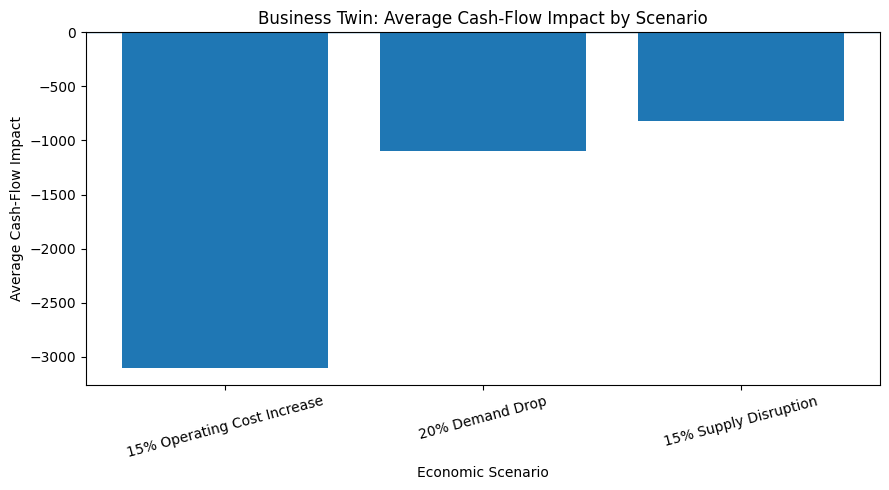

In [29]:
# Visualize Business Twin scenario impact

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    scenario_comparison["scenario"],
    scenario_comparison["average_cash_flow_impact"]
)

plt.axhline(0, linewidth=1)

plt.title("Business Twin: Average Cash-Flow Impact by Scenario")
plt.xlabel("Economic Scenario")
plt.ylabel("Average Cash-Flow Impact")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Business Twin Findings

The Business Twin Simulator evaluates how individual businesses respond to simulated economic stress conditions. Three independent scenarios were tested: a **20% demand drop**, a **15% supply disruption**, and a **15% operating cost increase**.

### Scenario Results

- **20% Demand Drop:** Average cash-flow impact of **−₹1,095.14**, with **34 businesses** becoming at risk.
- **15% Supply Disruption:** Average cash-flow impact of **−₹821.35**, with **34 businesses** becoming at risk.
- **15% Operating Cost Increase:** Average cash-flow impact of **−₹3,103.01**, with **174 businesses** becoming at risk.

The operating cost scenario produced the strongest negative impact, indicating that **cost pressure is the most significant simulated vulnerability across the business portfolio**.

### Business Risk Profile

Businesses were classified according to the number of scenarios under which they became cash-flow negative:

- **Low Risk:** 326 businesses
- **Moderate Risk:** 140 businesses
- **Critical Risk:** 34 businesses
- **High Risk:** 0 businesses

Food Vendors, Retail Shops, and Small Producers showed the highest levels of scenario vulnerability. Freelancers showed the strongest resilience, with no businesses becoming at risk under the three simulated scenarios.

Overall, the Business Twin demonstrates how scenario-based simulation can identify businesses that are particularly vulnerable to economic shocks and distinguish between businesses that experience financial losses and those that become financially unstable.